Building an Agentic System which autonomously will create Daily Performance Report for an E-Commerce Company

In [35]:
from langgraph.graph import StateGraph, START, END

In [36]:
!pip install langgraph langchain openai langchain_openai

In [37]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from typing_extensions import TypedDict

In [38]:
class ECommerce(TypedDict):

  #input
  visitors:int
  orders:int
  revenue:int

  #output
  conversion_rate:float
  average_order_value:float
  revenue_per_visitor:float

  #final output
  summary:str #this summary is nothing but the Daily Peformance Report

In [39]:
#Create a node to calculate conversion rate
def calculate_conversion_rate(state:ECommerce):
  visitors=state['visitors']
  orders=state['orders']

  rate=(orders/visitors) if visitors>0 else 0

  return {"conversion_rate":rate}

In [40]:
#Create a node to average order value
def calculate_avg_order_value(state:ECommerce):
  revenue=state['revenue']
  orders=state['orders']

  aov=(revenue/orders) if orders>0 else 0

  return {"average_order_value":aov}

In [41]:
#Create a node to calculate revenue per visitor
def calculate_revenue_per_visitor(state:ECommerce):
  revenue=state['revenue']
  visitors=state['visitors']

  rpv=(revenue/visitors) if visitors>0 else 0

  return {"revenue_per_visitor":rpv}

In [42]:
import os
os.environ["OPENAI_API_KEY"]=""

LLM=ChatOpenAI(model='gpt-4o-mini')

In [43]:
prompt=PromptTemplate(
    input_variables=["rate","aov","rpv"],
    template="""
    You are an ECommerce Business Analyst.
    Analyze the metrics provided and share insights

    Conversion Rate:{rate}
    Average Order Value:{aov}
    Revenue Per Visitor:{rpv}

    Give actionable business recommendations
    """
)

In [44]:
#creating a node for generating a summary report
def generate_summary(state):
  formatted_prompt=prompt.format(
      rate=state['conversion_rate'],
      aov=state['average_order_value'],
      rpv=state['revenue_per_visitor']
  )
  response=LLM.invoke(formatted_prompt)
  return {"summary":response.content}

In [45]:
#merging all the nodes together in the graph
graph=StateGraph(ECommerce)

#adding nodes
graph.add_node('calculate_conversion_rate', calculate_conversion_rate)
graph.add_node('calculate_avg_order_value', calculate_avg_order_value)
graph.add_node('calculate_revenue_per_visitor', calculate_revenue_per_visitor)
graph.add_node('generate_summary', generate_summary)


#adding edges
graph.add_edge(START, "calculate_conversion_rate")
graph.add_edge(START, "calculate_avg_order_value")
graph.add_edge(START, "calculate_revenue_per_visitor")
graph.add_edge("calculate_conversion_rate", "generate_summary")
graph.add_edge("calculate_avg_order_value", "generate_summary")
graph.add_edge("calculate_revenue_per_visitor", "generate_summary")
graph.add_edge("generate_summary", END)

In [46]:
#compiling the graph
workflow = graph.compile()

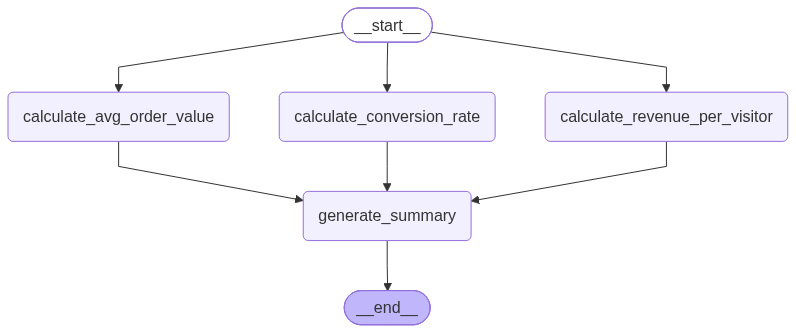

In [47]:
workflow

In [48]:
input_data={
    "visitors":10000,
    "orders":320,
    "revenue":250000
}

result=workflow.invoke(input_data)

In [49]:
print(result['summary'])

Analyzing the provided metrics, here's a breakdown:

### Metrics Review:

1. **Conversion Rate (CR): 0.032 (3.2%)**
   - This is relatively low for eCommerce businesses. A typical eCommerce conversion rate ranges from 2% to 5%, with top-performing websites often exceeding 5%. Therefore, there’s room for improvement in converting visitors into customers.

2. **Average Order Value (AOV): 781.25**
   - This is a high AOV compared to many eCommerce sectors, indicating that when users do make purchases, they are spending a significant amount. This suggests a potential market for high-value goods or a strong brand presence.

3. **Revenue Per Visitor (RPV): 25.0**
   - This indicates that, on average, every visitor generates $25 in revenue. With a conversion rate of 3.2%, it indicates that the average transaction is quite profitable, but the volume of transactions may not be high enough.

### Insights and Recommendations:

1. **Improve Conversion Rate:**
   - **A/B Testing:** Implement A/B te